### 📊 Análisis Exploratorio Comparativo: ReDIAL vs PEARL

## **TAMBIEN SE DEBE IMPORTAR UTILS.py**

Este notebook realiza un análisis descriptivo y comparativo de los dos datasets de recomendación conversacional utilizados en el proyecto: **ReDIAL** (orgánico, crowdsourced) y **PEARL** (sintético, generado por LLMs con persona y conocimiento). Ambos se procesan mediante el pipeline unificado de `utils.py`, que normaliza sus estructuras nativas a un formato común para garantizar comparabilidad directa.

#### Datasets analizados

| Aspecto | ReDIAL | PEARL |
|---|---|---|
| **Naturaleza** | Orgánico (AMT crowdworkers) | Sintético (simuladores LLM + reseñas reales) |
| **Formato nativo** | `.jsonl` con IDs numéricos (`@12345`) | `.json` con títulos explícitos en texto |
| **Roles** | Inferidos por `senderWorkerId` | Prefijos explícitos (`Seeker:` / `Recommender:`) |
| **Ground Truth** | Múltiple: sugeridas ∩ aceptadas (`gt_accepted`) | Única: `gt_movie_title` por diálogo |
| **Fuente** | `recwizard/redial` (HuggingFace) | `LangAGI-Lab/pearl` (HuggingFace) |

#### Estructura del análisis

1. **Setup y carga:** Importa `utils.py` y carga ambos datasets con `load_parsed(dataset=...)`, generando las muestras de evaluación (300 de test) y warmup (100 de train) con semilla fija (`seed=42`) para reproducibilidad.

2. **Estadísticas descriptivas (datasets completos):** Tabla comparativa de métricas estructurales (turnos, mensajes, palabras por mensaje, largo del contexto, cobertura de GT) para los 4 splits (redial_train, redial_test, pearl_train, pearl_test).

3. **Distribuciones visuales:** Histogramas de turnos por diálogo, largo de mensajes, boxplots del contexto generado por `build_context()`, cobertura de Ground Truth y tamaño de catálogo global.

4. **Análisis de muestras (300 eval + 100 warmup):** Replica las estadísticas sobre las muestras que efectivamente se usan en los experimentos, e incluye gráficos de representatividad (muestra vs dataset completo) para verificar ausencia de sesgo en el sampling.

5. **Frecuencia de películas en train:** Distribución de popularidad (document-frequency) que alimenta la métrica de Novelty. Revela el sesgo *long-tail* de cada dataset.

6. **Frecuencia de películas por diálogo (completos y muestras):** Análisis de repetición de películas en dos ejes: menciones generales (todas las apariciones en `title_map`) y Ground Truth (`gt_accepted`). Incluye rankings Top-20/15, curvas log-log de long-tail e histogramas de frecuencia.

#### Dependencia

Todas las funciones de carga y procesamiento provienen de **`utils.py`** (convertido desde `utils.ipynb`). Este archivo debe estar accesible en el path de Python antes de ejecutar el notebook:

```python
from utils import download_dataset, load_parsed, sample_conversations, build_context, ...
```

#### Parámetros compartidos con los experimentos

| Parámetro | Valor | Uso |
|---|---|---|
| `gt_field` | `gt_accepted` | Ground truth estricto en ambos datasets |
| `seed` | `42` | Sampling reproducible (mismas conversaciones que CoT, ACE, etc.) |
| `n_eval` | `300` | Conversaciones de test para evaluación |
| `n_warmup` | `100` | Conversaciones de train para warmup |

## 1. Setup

In [20]:
from utils import (
    download_dataset, load_parsed, sample_conversations,
    build_context, build_global_catalog,
    build_train_freq, build_recommender_references,
    _norm_title,
)

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ── Estilo global para los gráficos ──
plt.rcParams.update({
    "figure.figsize": (12, 5),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})

COLORS = {"redial": "#4C72B0", "pearl": "#DD8452"}

print("✅ Imports listos")

✅ Imports listos


## 2. Carga de datos

In [21]:
# ── Descargar y parsear ambos datasets ────────────────────────────
data = {}

for ds in ["redial", "pearl"]:
    paths = download_dataset(ds, splits=("train", "test"))
    train = load_parsed(paths["train"], dataset=ds)
    test = load_parsed(paths["test"], dataset=ds)
    catalog = build_global_catalog(train, test)

    # Samples con la misma semilla que los experimentos
    eval_sample = sample_conversations(test, n=300, gt_field="gt_accepted")
    warmup_sample = sample_conversations(train, n=100, gt_field="gt_accepted")

    data[ds] = {
        "paths": paths,
        "train": train,
        "test": test,
        "catalog": catalog,
        "eval_sample": eval_sample,
        "warmup_sample": warmup_sample,
    }

print("\n✅ Ambos datasets cargados y sampleados")

redial_train.jsonl ya existe, omitiendo descarga.
redial_test.jsonl ya existe, omitiendo descarga.
Catálogo global: 6083 películas
Sampled 300 conversaciones con gt_accepted no vacío (seed=42)
Sampled 100 conversaciones con gt_accepted no vacío (seed=42)
pearl_train.json ya existe, omitiendo descarga.
pearl_test.json ya existe, omitiendo descarga.
Catálogo global: 4 películas
Sampled 300 conversaciones con gt_accepted no vacío (seed=42)
Sampled 100 conversaciones con gt_accepted no vacío (seed=42)

✅ Ambos datasets cargados y sampleados


## 3. Análisis de datasets completos

In [22]:
# ── Funciones auxiliares para extraer estadísticas ────────────────

def compute_stats(parsed, label=""):
    """Calcula estadísticas descriptivas de una lista de diálogos parseados."""
    n = len(parsed)
    turns = [d["n_turns"] for d in parsed]
    n_messages = [len(d["messages"]) for d in parsed]
    seeker_movies = [len(d["seeker_movies"]) for d in parsed]
    gt_suggested = [len(d["gt_suggested"]) for d in parsed]
    gt_accepted = [len(d["gt_accepted"]) for d in parsed]
    catalog_sizes = [len(d["title_map"]) for d in parsed]

    # Largo promedio de mensajes (en palabras)
    msg_lengths = []
    for d in parsed:
        for m in d["messages"]:
            msg_lengths.append(len(m["text"].split()))

    # Largo del contexto (build_context) en palabras
    ctx_lengths = [len(build_context(d).split()) for d in parsed[:500]]  # cap a 500 por velocidad

    has_gt_suggested = sum(1 for d in parsed if d["gt_suggested"])
    has_gt_accepted = sum(1 for d in parsed if d["gt_accepted"])

    return {
        "label": label,
        "n_dialogues": n,
        "turns_mean": np.mean(turns),
        "turns_median": np.median(turns),
        "turns_std": np.std(turns),
        "messages_mean": np.mean(n_messages),
        "seeker_movies_mean": np.mean(seeker_movies),
        "gt_suggested_mean": np.mean(gt_suggested),
        "gt_accepted_mean": np.mean(gt_accepted),
        "catalog_per_dialogue": np.mean(catalog_sizes),
        "msg_words_mean": np.mean(msg_lengths),
        "msg_words_median": np.median(msg_lengths),
        "ctx_words_mean": np.mean(ctx_lengths),
        "ctx_words_median": np.median(ctx_lengths),
        "has_gt_suggested_pct": has_gt_suggested / n * 100,
        "has_gt_accepted_pct": has_gt_accepted / n * 100,
        "turns_list": turns,
        "msg_lengths_list": msg_lengths,
        "ctx_lengths_list": ctx_lengths,
        "gt_suggested_list": gt_suggested,
    }


def print_stats_table(stats_dict):
    """Imprime una tabla comparativa de estadísticas."""
    keys = list(stats_dict.keys())
    print(f"{'Métrica':<35}", end="")
    for k in keys:
        print(f"{k:>15}", end="")
    print()
    print("-" * (35 + 15 * len(keys)))

    rows = [
        ("N diálogos", "n_dialogues", ".0f"),
        ("Turnos (media)", "turns_mean", ".1f"),
        ("Turnos (mediana)", "turns_median", ".0f"),
        ("Turnos (std)", "turns_std", ".1f"),
        ("Mensajes limpios (media)", "messages_mean", ".1f"),
        ("Películas del seeker (media)", "seeker_movies_mean", ".1f"),
        ("GT sugeridas (media)", "gt_suggested_mean", ".2f"),
        ("GT aceptadas (media)", "gt_accepted_mean", ".2f"),
        ("Películas en title_map (media)", "catalog_per_dialogue", ".1f"),
        ("Palabras por mensaje (media)", "msg_words_mean", ".1f"),
        ("Palabras por mensaje (mediana)", "msg_words_median", ".0f"),
        ("Palabras en contexto (media)", "ctx_words_mean", ".1f"),
        ("% con GT sugeridas", "has_gt_suggested_pct", ".1f"),
        ("% con GT aceptadas", "has_gt_accepted_pct", ".1f"),
    ]
    for label, key, fmt in rows:
        print(f"{label:<35}", end="")
        for k in keys:
            val = stats_dict[k][key]
            print(f"{val:>15{fmt}}", end="")
        print()


print("✅ Helpers definidos")

✅ Helpers definidos


In [23]:
# ── Estadísticas de los datasets completos ────────────────────────
full_stats = {}
for ds in ["redial", "pearl"]:
    for split in ["train", "test"]:
        key = f"{ds}_{split}"
        full_stats[key] = compute_stats(data[ds][split], label=key)

print("=== DATASETS COMPLETOS ===\n")
print_stats_table(full_stats)

=== DATASETS COMPLETOS ===

Métrica                               redial_train    redial_test    pearl_train     pearl_test
-----------------------------------------------------------------------------------------------
N diálogos                                    8004           1342          50000           2277
Turnos (media)                                18.2           17.8            9.6            9.6
Turnos (mediana)                                17             17              9              9
Turnos (std)                                   5.4            5.0            1.3            1.3
Mensajes limpios (media)                      18.2           17.8            9.3            9.3
Películas del seeker (media)                   1.6            1.9            3.0            3.0
GT sugeridas (media)                          3.55           3.30           1.00           1.00
GT aceptadas (media)                          2.73           2.48           1.00           1.00
Películas en

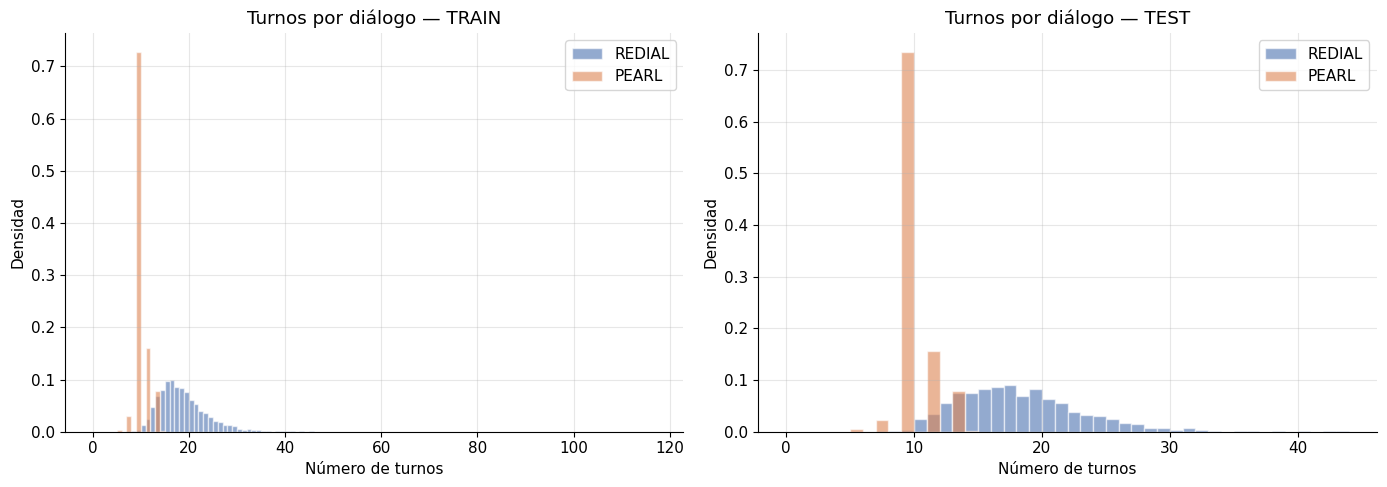

In [24]:
# ── Gráfico 1: Distribución de turnos por diálogo ────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, split in zip(axes, ["train", "test"]):
    for ds in ["redial", "pearl"]:
        key = f"{ds}_{split}"
        turns = full_stats[key]["turns_list"]
        ax.hist(turns, bins=range(0, max(turns) + 2), alpha=0.6,
                color=COLORS[ds], label=f"{ds.upper()}", density=True, edgecolor="white")
    ax.set_title(f"Turnos por diálogo — {split.upper()}")
    ax.set_xlabel("Número de turnos")
    ax.set_ylabel("Densidad")
    ax.legend()

plt.tight_layout()
plt.show()

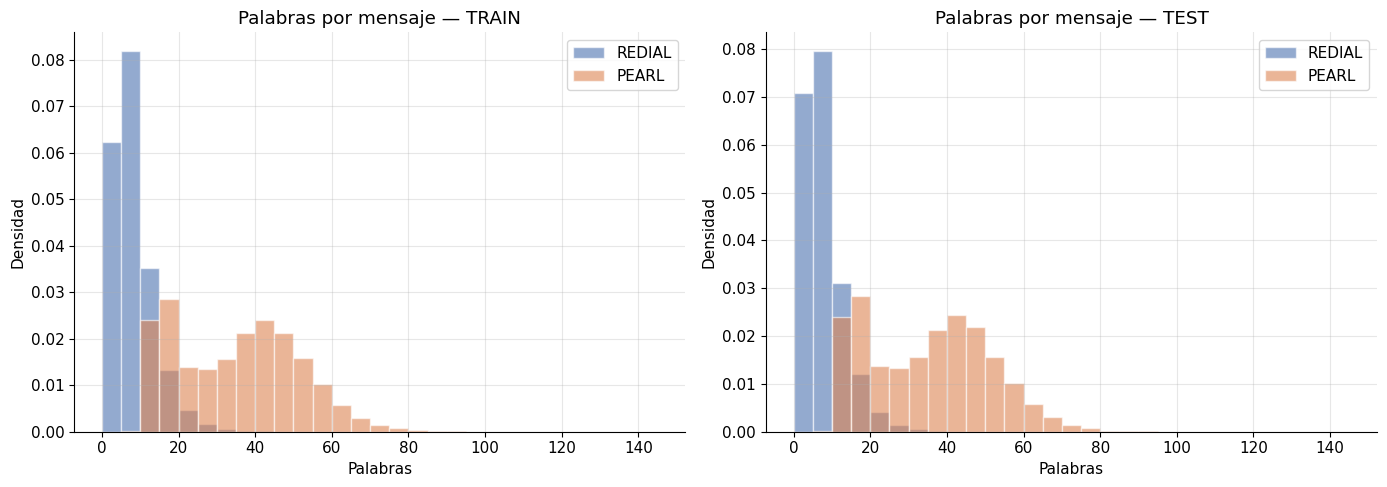

In [25]:
# ── Gráfico 2: Distribución de largo de mensajes (palabras) ──────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, split in zip(axes, ["train", "test"]):
    for ds in ["redial", "pearl"]:
        key = f"{ds}_{split}"
        lengths = full_stats[key]["msg_lengths_list"]
        ax.hist(lengths, bins=range(0, 150, 5), alpha=0.6,
                color=COLORS[ds], label=f"{ds.upper()}", density=True, edgecolor="white")
    ax.set_title(f"Palabras por mensaje — {split.upper()}")
    ax.set_xlabel("Palabras")
    ax.set_ylabel("Densidad")
    ax.legend()

plt.tight_layout()
plt.show()

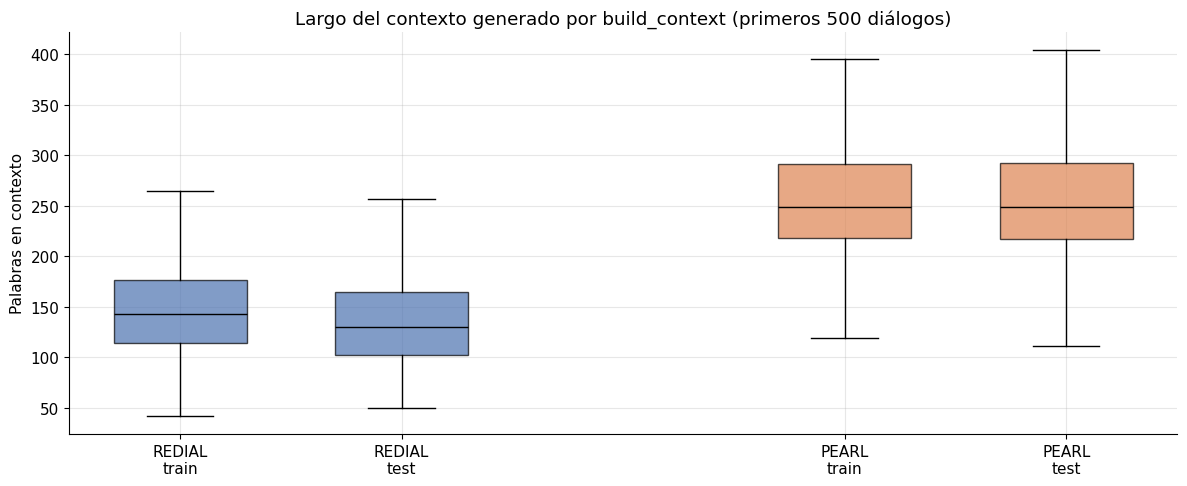

In [26]:
# ── Gráfico 3: Largo del contexto (build_context) ────────────────
fig, ax = plt.subplots(figsize=(12, 5))

positions = []
labels = []
box_data = []

for i, ds in enumerate(["redial", "pearl"]):
    for j, split in enumerate(["train", "test"]):
        key = f"{ds}_{split}"
        box_data.append(full_stats[key]["ctx_lengths_list"])
        positions.append(i * 3 + j)
        labels.append(f"{ds.upper()}\n{split}")

bp = ax.boxplot(box_data, positions=positions, widths=0.6, patch_artist=True,
                showfliers=False, medianprops=dict(color="black"))

colors_box = [COLORS["redial"], COLORS["redial"], COLORS["pearl"], COLORS["pearl"]]
for patch, color in zip(bp["boxes"], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_xticks(positions)
ax.set_xticklabels(labels)
ax.set_ylabel("Palabras en contexto")
ax.set_title("Largo del contexto generado por build_context (primeros 500 diálogos)")
plt.tight_layout()
plt.show()

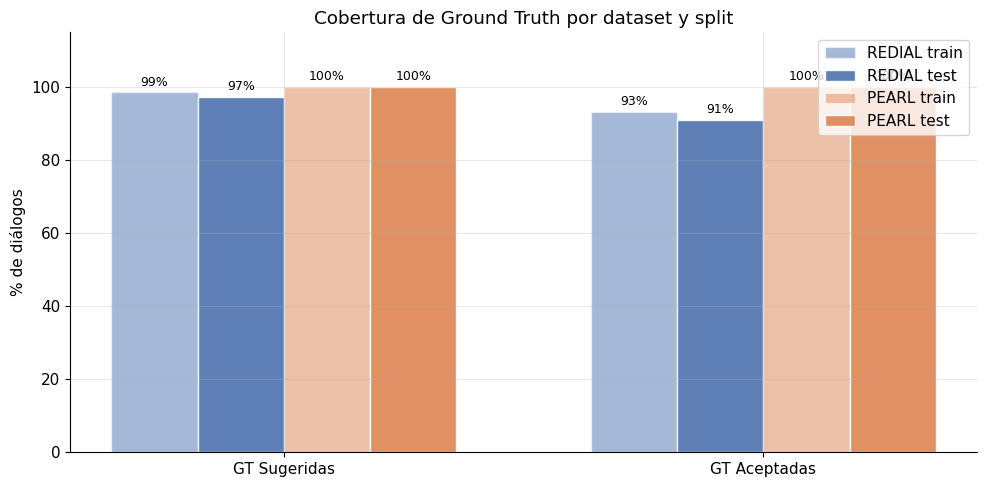

In [27]:
# ── Gráfico 4: Cobertura de Ground Truth ─────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

gt_fields = ["has_gt_suggested_pct", "has_gt_accepted_pct"]
gt_labels = ["GT Sugeridas", "GT Aceptadas"]
x = np.arange(len(gt_labels))
width = 0.18

for i, (ds, split) in enumerate([("redial", "train"), ("redial", "test"),
                                   ("pearl", "train"), ("pearl", "test")]):
    key = f"{ds}_{split}"
    vals = [full_stats[key][f] for f in gt_fields]
    offset = (i - 1.5) * width
    bars = ax.bar(x + offset, vals, width, label=f"{ds.upper()} {split}",
                  color=COLORS[ds], alpha=0.9 if split == "test" else 0.5,
                  edgecolor="white")
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                f"{val:.0f}%", ha="center", va="bottom", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(gt_labels)
ax.set_ylabel("% de diálogos")
ax.set_title("Cobertura de Ground Truth por dataset y split")
ax.set_ylim(0, 115)
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

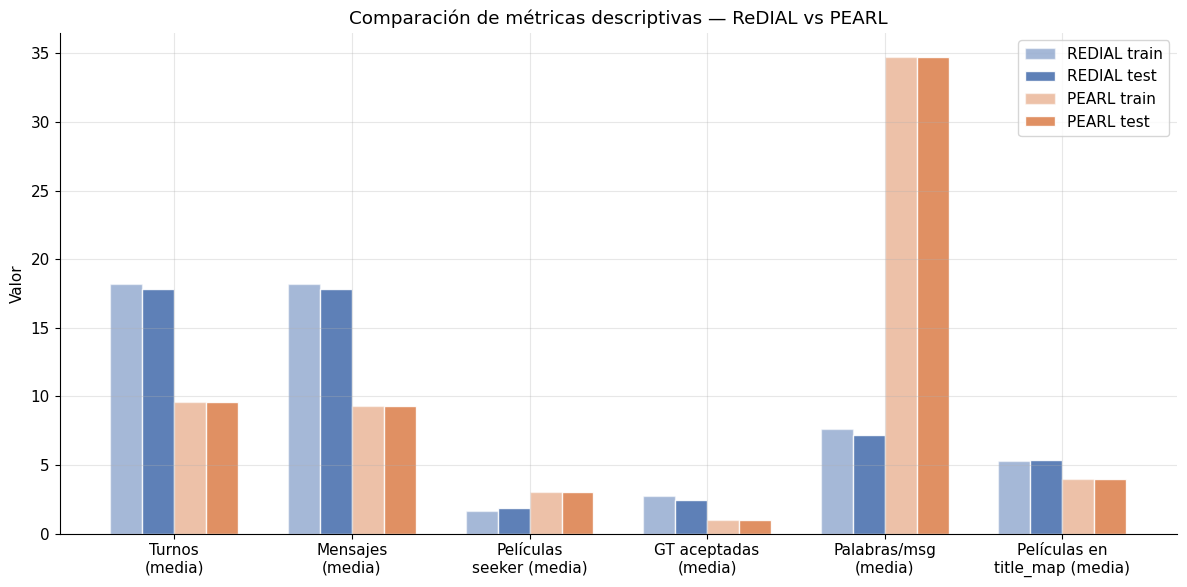

In [28]:
# ── Gráfico 5: Resumen comparativo (barplot) ─────────────────────
fig, ax = plt.subplots(figsize=(12, 6))

metrics_to_compare = [
    ("turns_mean", "Turnos\n(media)"),
    ("messages_mean", "Mensajes\n(media)"),
    ("seeker_movies_mean", "Películas\nseeker (media)"),
    ("gt_accepted_mean", "GT aceptadas\n(media)"),
    ("msg_words_mean", "Palabras/msg\n(media)"),
    ("catalog_per_dialogue", "Películas en\ntitle_map (media)"),
]

x = np.arange(len(metrics_to_compare))
width = 0.18

for i, (ds, split) in enumerate([("redial", "train"), ("redial", "test"),
                                   ("pearl", "train"), ("pearl", "test")]):
    key = f"{ds}_{split}"
    vals = [full_stats[key][m[0]] for m in metrics_to_compare]
    offset = (i - 1.5) * width
    ax.bar(x + offset, vals, width, label=f"{ds.upper()} {split}",
           color=COLORS[ds], alpha=0.9 if split == "test" else 0.5,
           edgecolor="white")

ax.set_xticks(x)
ax.set_xticklabels([m[1] for m in metrics_to_compare])
ax.set_ylabel("Valor")
ax.set_title("Comparación de métricas descriptivas — ReDIAL vs PEARL")
ax.legend()
plt.tight_layout()
plt.show()

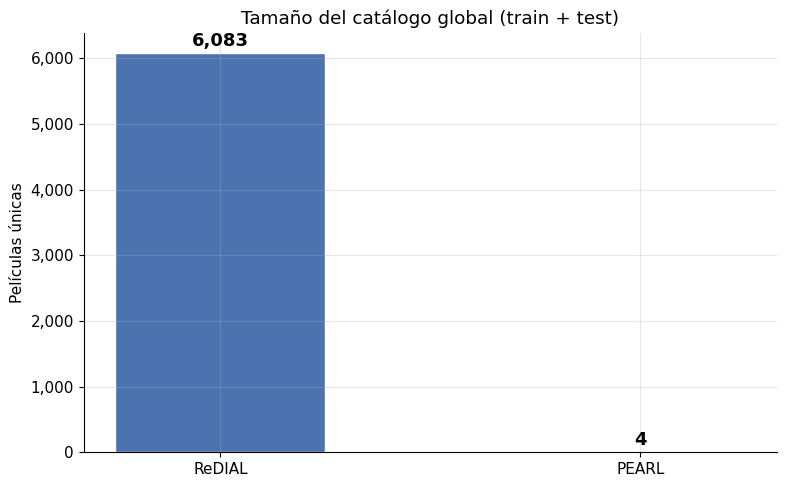

In [29]:
# ── Gráfico 6: Tamaño de catálogo global ─────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

catalog_sizes = [len(data[ds]["catalog"]) for ds in ["redial", "pearl"]]
bars = ax.bar(["ReDIAL", "PEARL"], catalog_sizes,
              color=[COLORS["redial"], COLORS["pearl"]], edgecolor="white", width=0.5)

for bar, val in zip(bars, catalog_sizes):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 50,
            f"{val:,}", ha="center", va="bottom", fontsize=13, fontweight="bold")

ax.set_ylabel("Películas únicas")
ax.set_title("Tamaño del catálogo global (train + test)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.show()

## 4. Análisis de muestras (300 eval + 100 warmup)

In [30]:
# ── Estadísticas de las muestras ──────────────────────────────────
sample_stats = {}
for ds in ["redial", "pearl"]:
    sample_stats[f"{ds}_eval300"] = compute_stats(data[ds]["eval_sample"], label=f"{ds}_eval300")
    sample_stats[f"{ds}_warmup100"] = compute_stats(data[ds]["warmup_sample"], label=f"{ds}_warmup100")

print("=== MUESTRAS (300 eval + 100 warmup) ===\n")
print_stats_table(sample_stats)

=== MUESTRAS (300 eval + 100 warmup) ===

Métrica                             redial_eval300redial_warmup100  pearl_eval300pearl_warmup100
-----------------------------------------------------------------------------------------------
N diálogos                                     300            100            300            100
Turnos (media)                                18.4           18.6            9.5            9.6
Turnos (mediana)                                18             18              9              9
Turnos (std)                                   5.4            5.4            1.3            1.3
Mensajes limpios (media)                      18.4           18.6            9.2            9.2
Películas del seeker (media)                   1.8            1.4            3.0            3.0
GT sugeridas (media)                          3.52           3.91           1.00           1.00
GT aceptadas (media)                          2.85           2.93           1.00           1.

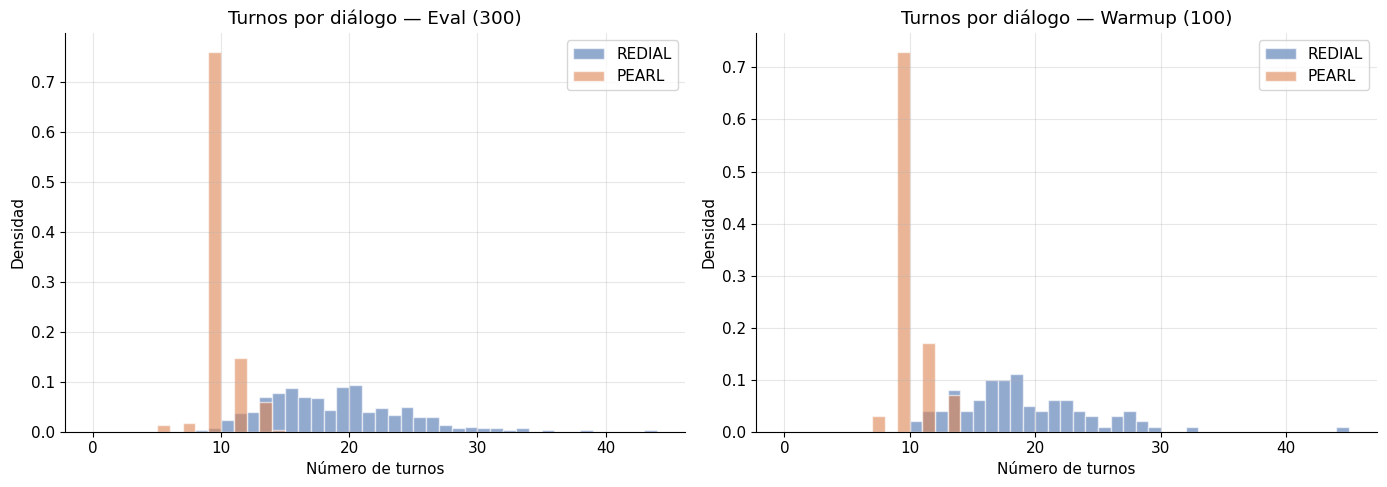

In [31]:
# ── Gráfico 7: Distribución de turnos en muestras ────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (sample_key, title) in zip(axes, [("eval300", "Eval (300)"), ("warmup100", "Warmup (100)")]):
    for ds in ["redial", "pearl"]:
        key = f"{ds}_{sample_key}"
        turns = sample_stats[key]["turns_list"]
        ax.hist(turns, bins=range(0, max(turns) + 2), alpha=0.6,
                color=COLORS[ds], label=f"{ds.upper()}", density=True, edgecolor="white")
    ax.set_title(f"Turnos por diálogo — {title}")
    ax.set_xlabel("Número de turnos")
    ax.set_ylabel("Densidad")
    ax.legend()

plt.tight_layout()
plt.show()

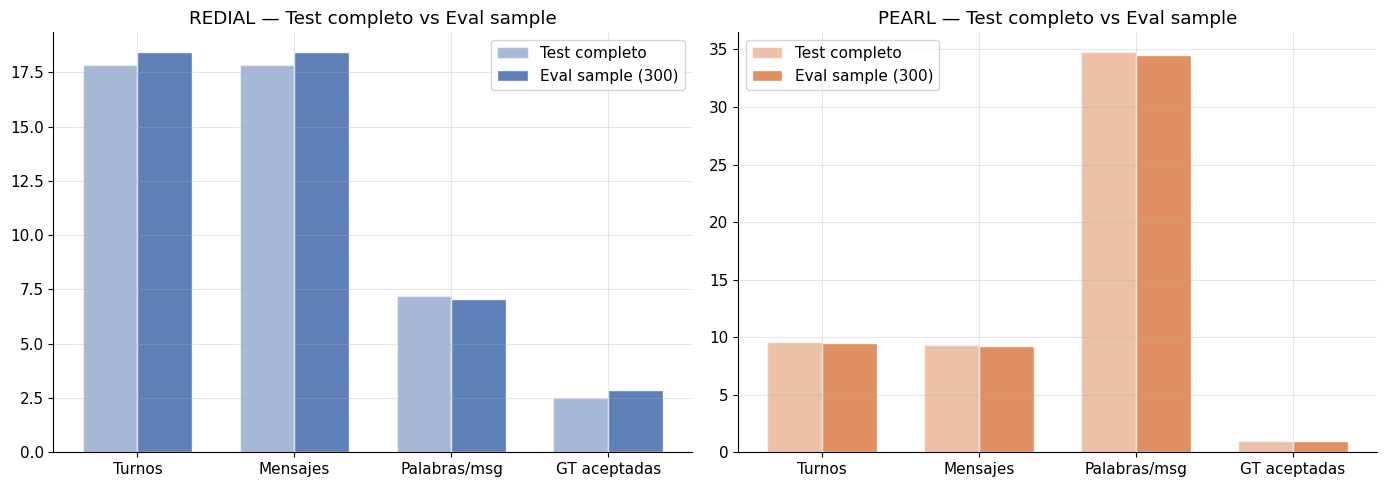

In [32]:
# ── Gráfico 8: Comparación muestra vs dataset completo ───────────
# Verificar que las muestras son representativas

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, ds in zip(axes, ["redial", "pearl"]):
    metrics_compare = ["turns_mean", "messages_mean", "msg_words_mean", "gt_accepted_mean"]
    labels_compare = ["Turnos", "Mensajes", "Palabras/msg", "GT aceptadas"]

    # Valores del dataset completo (test para eval, train para warmup)
    full_test_vals = [full_stats[f"{ds}_test"][m] for m in metrics_compare]
    sample_eval_vals = [sample_stats[f"{ds}_eval300"][m] for m in metrics_compare]

    x = np.arange(len(metrics_compare))
    width = 0.35

    ax.bar(x - width/2, full_test_vals, width, label="Test completo",
           color=COLORS[ds], alpha=0.5, edgecolor="white")
    ax.bar(x + width/2, sample_eval_vals, width, label="Eval sample (300)",
           color=COLORS[ds], alpha=0.9, edgecolor="white")

    ax.set_xticks(x)
    ax.set_xticklabels(labels_compare)
    ax.set_title(f"{ds.upper()} — Test completo vs Eval sample")
    ax.legend()

plt.tight_layout()
plt.show()

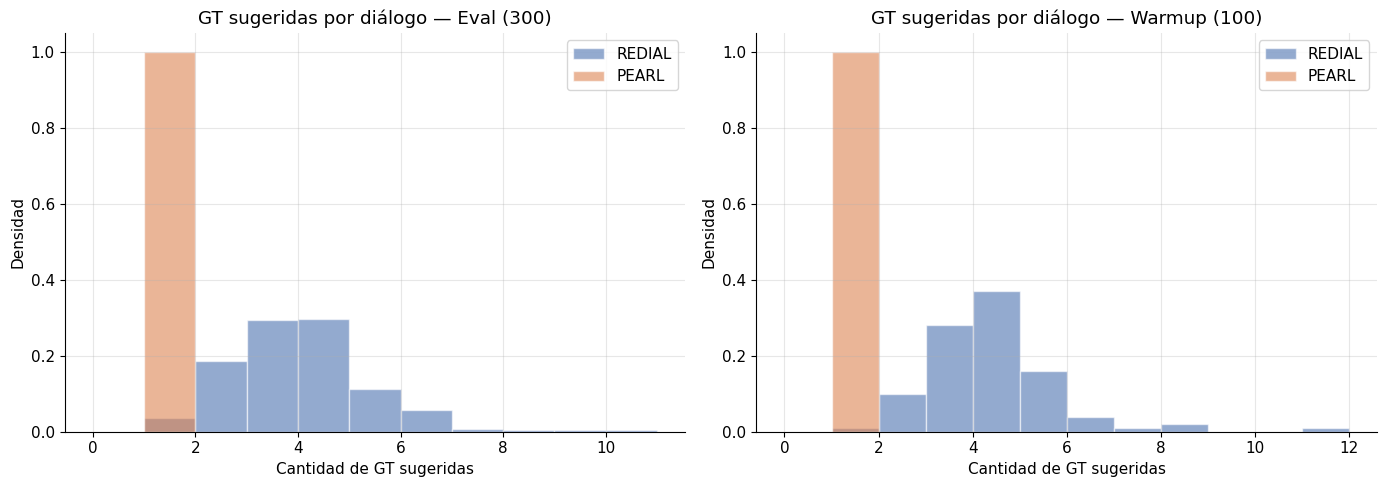

In [33]:
# ── Gráfico 9: GT por diálogo en las muestras ────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (sample_key, title) in zip(axes, [("eval300", "Eval (300)"), ("warmup100", "Warmup (100)")]):
    for ds in ["redial", "pearl"]:
        key = f"{ds}_{sample_key}"
        gt_counts = sample_stats[key]["gt_suggested_list"]
        max_gt = max(gt_counts) + 1
        ax.hist(gt_counts, bins=range(0, max_gt + 1), alpha=0.6,
                color=COLORS[ds], label=f"{ds.upper()}", density=True, edgecolor="white")
    ax.set_title(f"GT sugeridas por diálogo — {title}")
    ax.set_xlabel("Cantidad de GT sugeridas")
    ax.set_ylabel("Densidad")
    ax.legend()

plt.tight_layout()
plt.show()

## 5. Frecuencia de películas en train (Novelty)

Train freq construido: 5220 títulos únicos en 8004 diálogos
REDIAL: 5220 títulos únicos, media=8.0, mediana=2, max=470, min=1
Train freq construido: 9303 títulos únicos en 50000 diálogos
PEARL: 9303 títulos únicos, media=21.5, mediana=10, max=427, min=1


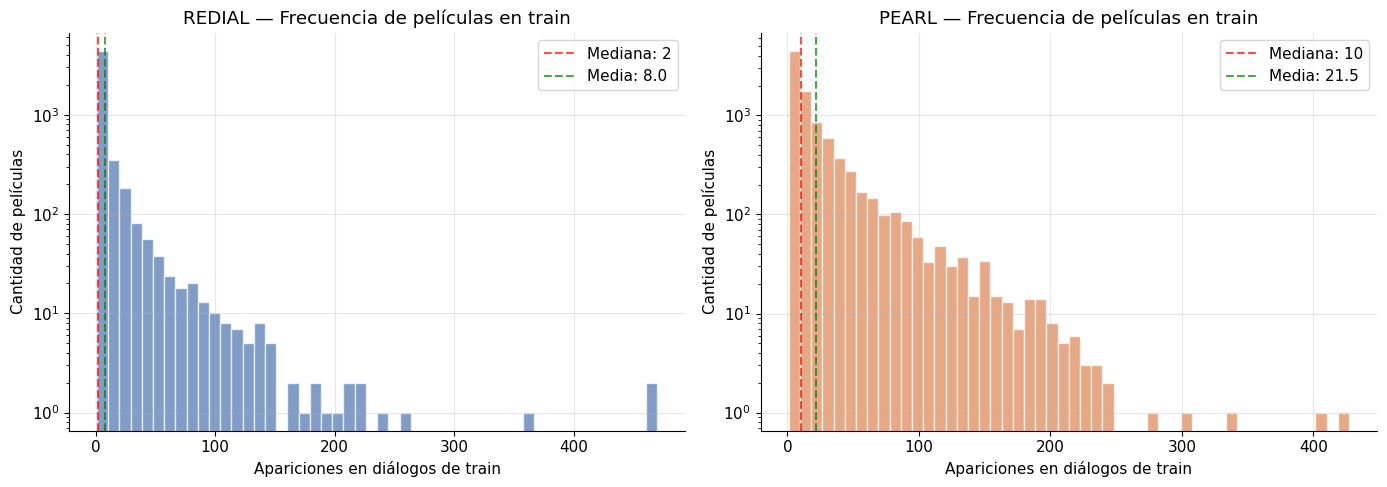

In [34]:
# ── Gráfico 10: Distribución de frecuencia en train ──────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, ds in zip(axes, ["redial", "pearl"]):
    train_freq, n_train = build_train_freq(data[ds]["paths"]["train"], dataset=ds)
    freqs = list(train_freq.values())

    ax.hist(freqs, bins=50, color=COLORS[ds], alpha=0.7, edgecolor="white")
    ax.set_title(f"{ds.upper()} — Frecuencia de películas en train")
    ax.set_xlabel("Apariciones en diálogos de train")
    ax.set_ylabel("Cantidad de películas")
    ax.set_yscale("log")

    # Estadísticas
    ax.axvline(np.median(freqs), color="red", linestyle="--", alpha=0.7, label=f"Mediana: {np.median(freqs):.0f}")
    ax.axvline(np.mean(freqs), color="green", linestyle="--", alpha=0.7, label=f"Media: {np.mean(freqs):.1f}")
    ax.legend()

    print(f"{ds.upper()}: {len(train_freq)} títulos únicos, "
          f"media={np.mean(freqs):.1f}, mediana={np.median(freqs):.0f}, "
          f"max={max(freqs)}, min={min(freqs)}")

plt.tight_layout()
plt.show()

## 6. Resumen

In [35]:
# ── Tabla resumen final ───────────────────────────────────────────
print("=" * 70)
print("  RESUMEN COMPARATIVO")
print("=" * 70)

for ds in ["redial", "pearl"]:
    d = data[ds]
    print(f"\n  {ds.upper()}")
    print(f"    Train: {len(d['train']):>7,} diálogos")
    print(f"    Test:  {len(d['test']):>7,} diálogos")
    print(f"    Catálogo: {len(d['catalog']):>6,} películas únicas")

    pct_train = sum(1 for x in d["train"] if x["gt_accepted"]) / len(d["train"]) * 100
    pct_test = sum(1 for x in d["test"] if x["gt_accepted"]) / len(d["test"]) * 100
    print(f"    % con GT aceptadas: train={pct_train:.1f}%  test={pct_test:.1f}%")

    eval_s = d["eval_sample"]
    warmup_s = d["warmup_sample"]
    print(f"    Eval sample:   {len(eval_s)} diálogos (de test)")
    print(f"    Warmup sample: {len(warmup_s)} diálogos (de train)")

print(f"\n{'=' * 70}")
print("  Ambos datasets comparten el mismo formato de salida de load_parsed.")
print("  Las muestras son representativas de sus datasets originales.")
print("=" * 70)

  RESUMEN COMPARATIVO

  REDIAL
    Train:   8,004 diálogos
    Test:    1,342 diálogos
    Catálogo:  6,083 películas únicas
    % con GT aceptadas: train=93.2%  test=91.0%
    Eval sample:   300 diálogos (de test)
    Warmup sample: 100 diálogos (de train)

  PEARL
    Train:  50,000 diálogos
    Test:    2,277 diálogos
    Catálogo:      4 películas únicas
    % con GT aceptadas: train=100.0%  test=100.0%
    Eval sample:   300 diálogos (de test)
    Warmup sample: 100 diálogos (de train)

  Ambos datasets comparten el mismo formato de salida de load_parsed.
  Las muestras son representativas de sus datasets originales.


REDIAL (train+test) — Películas únicas (general): 6077 | GT: 4411
PEARL (train+test) — Películas únicas (general): 9633 | GT: 7660


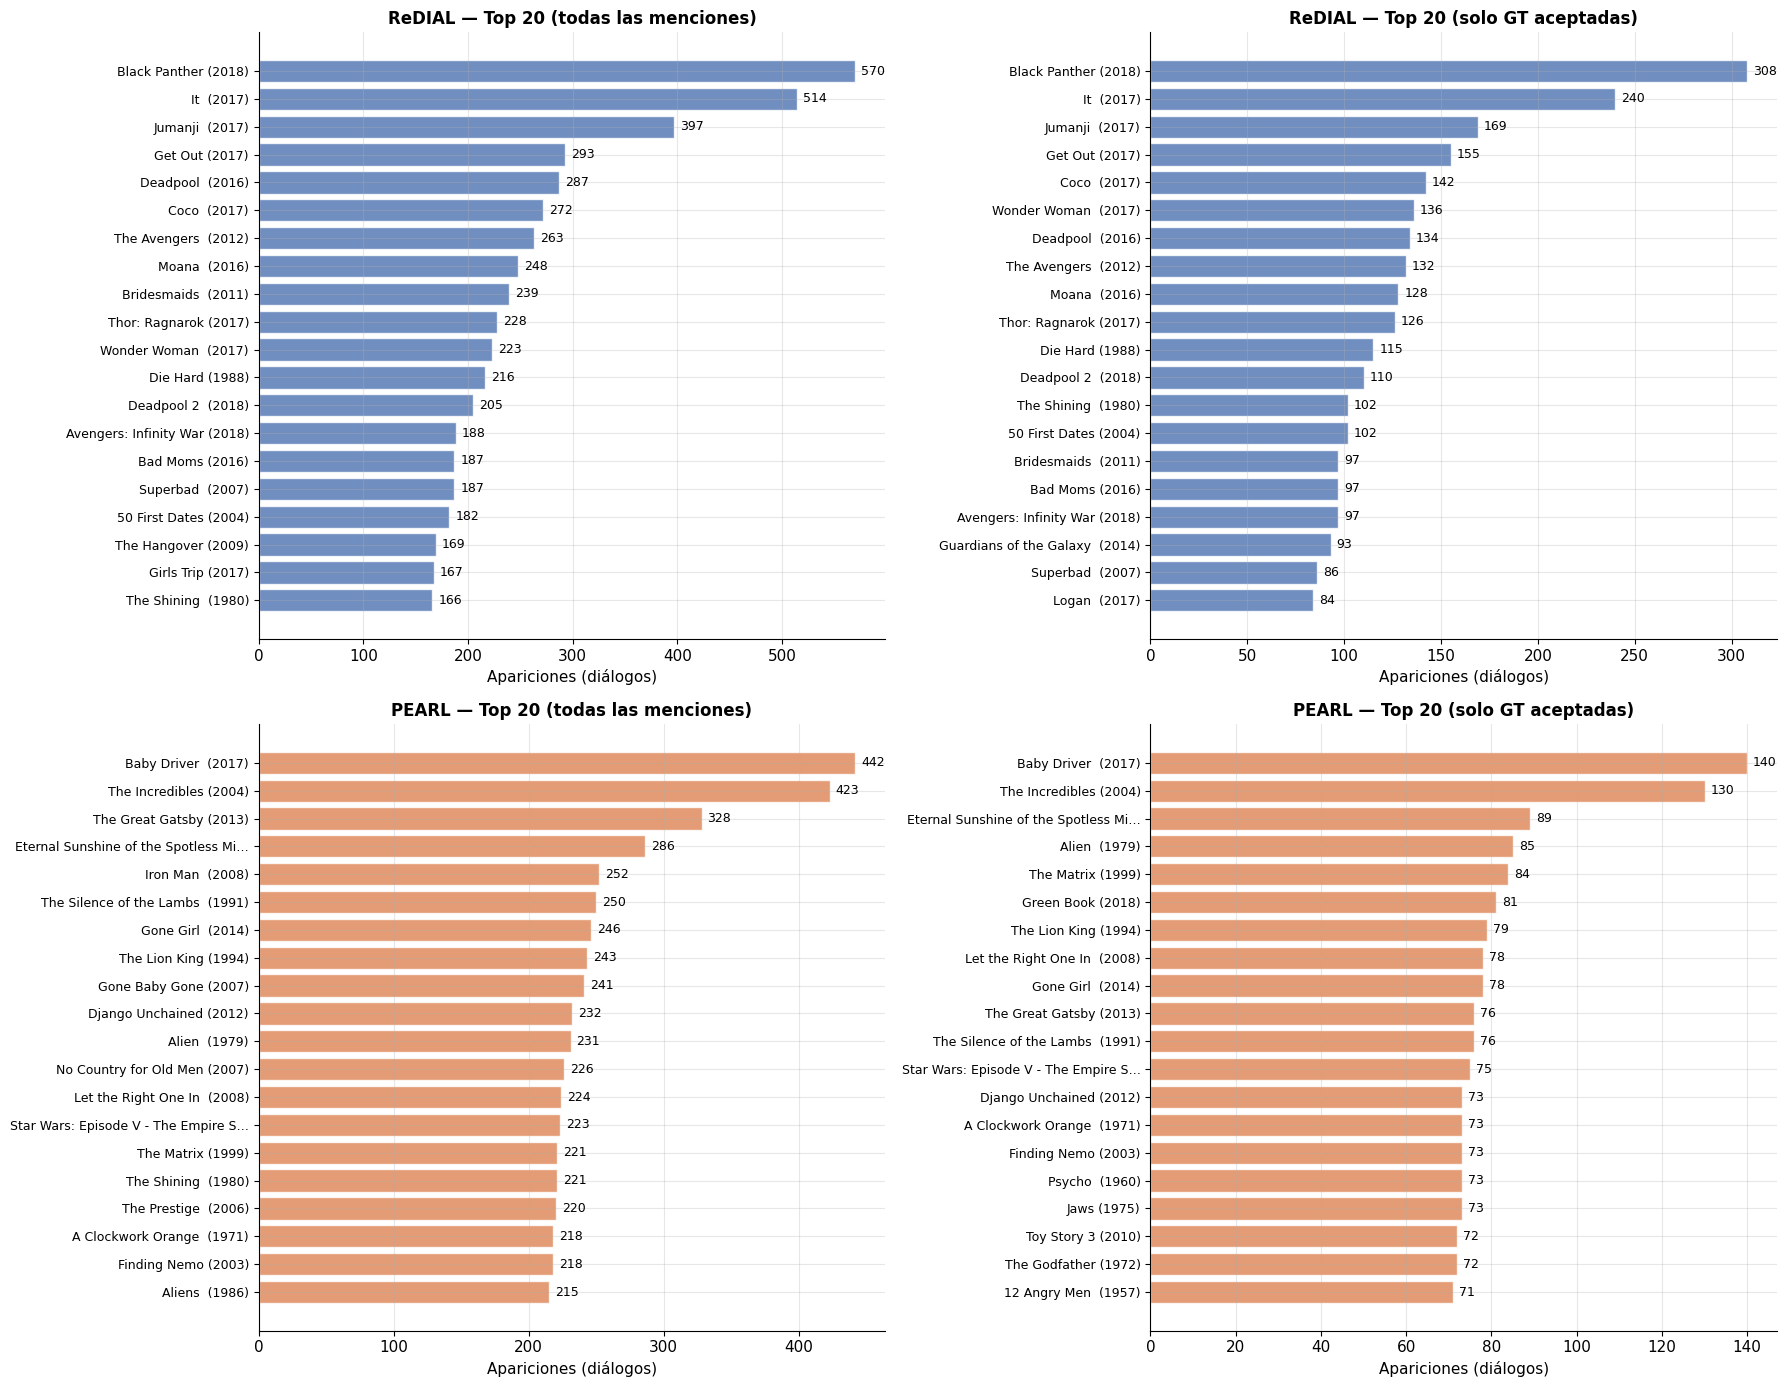

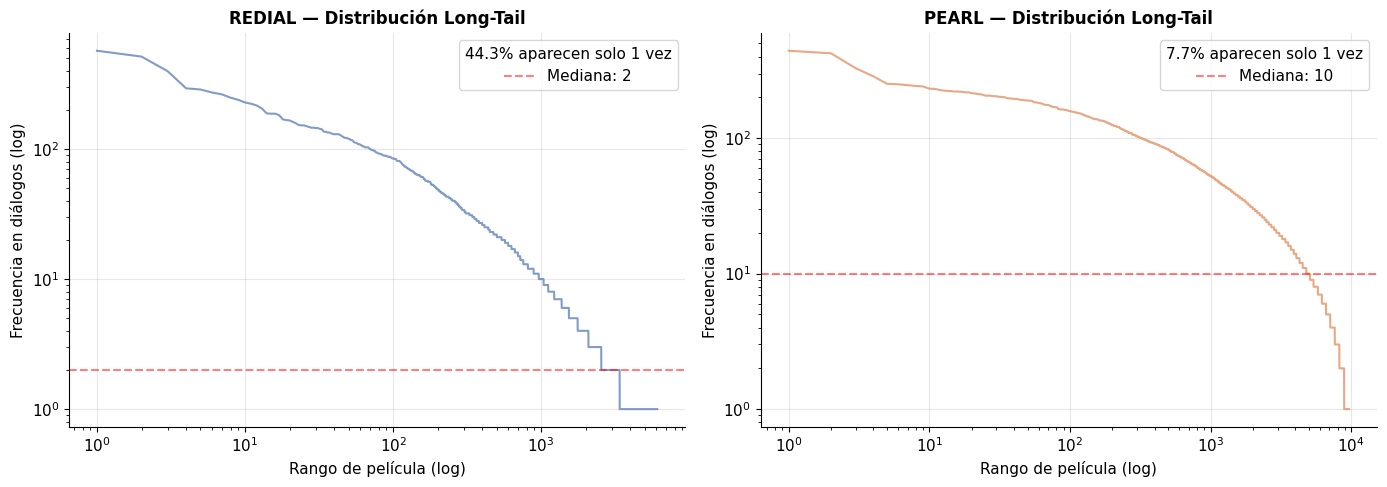

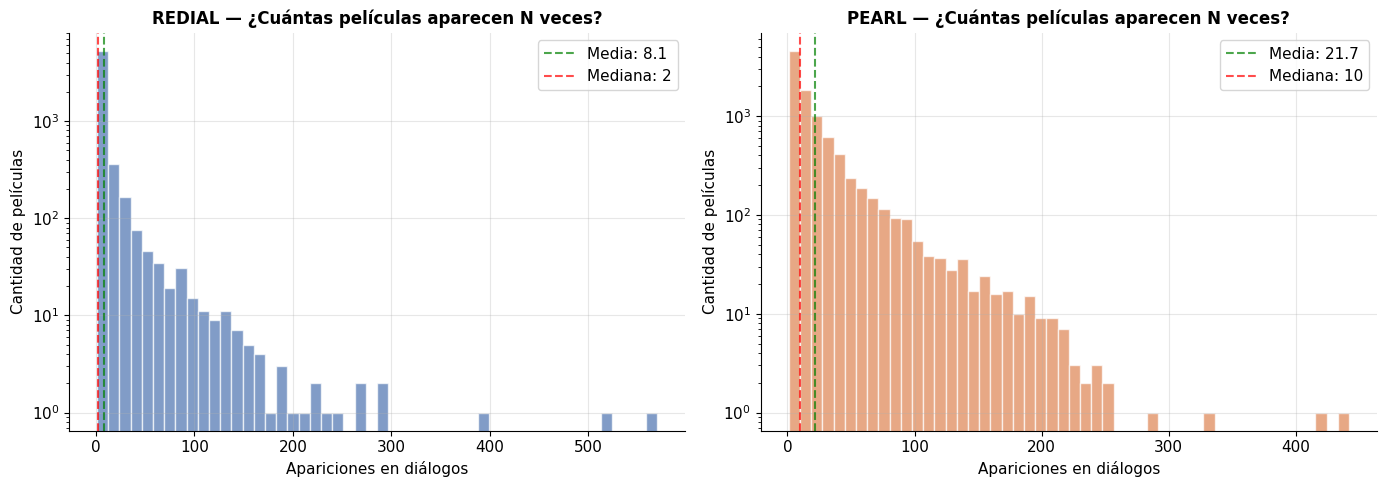


  RESUMEN DE FRECUENCIA DE PELÍCULAS (train + test)

  REDIAL:
    Películas únicas (general): 6,077
    Películas únicas (GT):      4,411
    Frecuencia media (general): 8.1 diálogos
    Frecuencia media (GT):      5.7 diálogos
    Aparecen solo 1 vez:        2,692 (44.3%)
    GT aparece solo 1 vez:      2,099 (47.6%)
    Más frecuente (general):    Black Panther (2018) (570 diálogos)
    Más frecuente (GT):         Black Panther (2018) (308 diálogos)

  PEARL:
    Películas únicas (general): 9,633
    Películas únicas (GT):      7,660
    Frecuencia media (general): 21.7 diálogos
    Frecuencia media (GT):      6.8 diálogos
    Aparecen solo 1 vez:        745 (7.7%)
    GT aparece solo 1 vez:      2,024 (26.4%)
    Más frecuente (general):    Baby Driver  (2017) (442 diálogos)
    Más frecuente (GT):         Baby Driver  (2017) (140 diálogos)



In [36]:
# ── Frecuencia de películas por diálogo (datasets completos) ─────
from collections import Counter

def count_freqs(parsed_list):
    """Cuenta frecuencia general (title_map) y GT (gt_accepted) por diálogo."""
    general = Counter()
    gt = Counter()
    for d in parsed_list:
        tmap = d["title_map"]
        seen = set()
        for title in tmap.values():
            if title and title.strip():
                seen.add(title.strip())
        for t in seen:
            general[t] += 1
        for mid in d["gt_accepted"]:
            title = tmap.get(mid, "").strip()
            if title:
                gt[title] += 1
    return general, gt

# Calcular para train + test combinados
freq_full = {}
for ds in ["redial", "pearl"]:
    combined = data[ds]["train"] + data[ds]["test"]
    gen, gt = count_freqs(combined)
    freq_full[ds] = {"general": gen, "gt": gt}
    print(f"{ds.upper()} (train+test) — Películas únicas (general): {len(gen)} | GT: {len(gt)}")

# =============================================
# TOP 20 MÁS FRECUENTES
# =============================================
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

plots = [
    (freq_full["redial"]["general"], "ReDIAL — Top 20 (todas las menciones)", COLORS["redial"]),
    (freq_full["redial"]["gt"], "ReDIAL — Top 20 (solo GT aceptadas)", COLORS["redial"]),
    (freq_full["pearl"]["general"], "PEARL — Top 20 (todas las menciones)", COLORS["pearl"]),
    (freq_full["pearl"]["gt"], "PEARL — Top 20 (solo GT aceptadas)", COLORS["pearl"]),
]

for ax, (counter, title, color) in zip(axes.flat, plots):
    top20 = counter.most_common(20)
    names = [t[0][:35] + "…" if len(t[0]) > 35 else t[0] for t in top20]
    counts = [t[1] for t in top20]
    y_pos = np.arange(len(names))

    ax.barh(y_pos, counts, color=color, alpha=0.8, edgecolor="white")
    ax.set_yticks(y_pos)
    ax.set_yticklabels(names, fontsize=9)
    ax.invert_yaxis()
    ax.set_xlabel("Apariciones (diálogos)")
    ax.set_title(title, fontsize=12, fontweight="bold")
    for i, v in enumerate(counts):
        ax.text(v + max(counts) * 0.01, i, str(v), va="center", fontsize=9)

plt.tight_layout()
plt.show()

# =============================================
# DISTRIBUCIÓN LONG-TAIL (log-log)
# =============================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, ds, color in zip(axes, ["redial", "pearl"], [COLORS["redial"], COLORS["pearl"]]):
    freqs = sorted(freq_full[ds]["general"].values(), reverse=True)
    ranks = np.arange(1, len(freqs) + 1)

    ax.loglog(ranks, freqs, color=color, alpha=0.7, linewidth=1.5)
    ax.set_xlabel("Rango de película (log)")
    ax.set_ylabel("Frecuencia en diálogos (log)")
    ax.set_title(f"{ds.upper()} — Distribución Long-Tail", fontsize=12, fontweight="bold")
    ax.grid(True, alpha=0.3)

    pct_once = sum(1 for f in freqs if f == 1) / len(freqs) * 100
    ax.axhline(y=np.median(freqs), color="red", linestyle="--", alpha=0.5,
               label=f"Mediana: {np.median(freqs):.0f}")
    ax.legend(title=f"{pct_once:.1f}% aparecen solo 1 vez")

plt.tight_layout()
plt.show()

# =============================================
# HISTOGRAMA DE FRECUENCIAS
# =============================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, ds, color in zip(axes, ["redial", "pearl"], [COLORS["redial"], COLORS["pearl"]]):
    freqs = list(freq_full[ds]["general"].values())
    ax.hist(freqs, bins=50, color=color, alpha=0.7, edgecolor="white")
    ax.set_xlabel("Apariciones en diálogos")
    ax.set_ylabel("Cantidad de películas")
    ax.set_title(f"{ds.upper()} — ¿Cuántas películas aparecen N veces?", fontsize=12, fontweight="bold")
    ax.set_yscale("log")

    ax.axvline(np.mean(freqs), color="green", linestyle="--", alpha=0.7,
               label=f"Media: {np.mean(freqs):.1f}")
    ax.axvline(np.median(freqs), color="red", linestyle="--", alpha=0.7,
               label=f"Mediana: {np.median(freqs):.0f}")
    ax.legend()

plt.tight_layout()
plt.show()

# =============================================
# RESUMEN
# =============================================
print("\n" + "=" * 60)
print("  RESUMEN DE FRECUENCIA DE PELÍCULAS (train + test)")
print("=" * 60)

for ds in ["redial", "pearl"]:
    gen = freq_full[ds]["general"]
    gt = freq_full[ds]["gt"]
    freqs_g = list(gen.values())
    freqs_gt = list(gt.values())
    once_g = sum(1 for f in freqs_g if f == 1)
    once_gt = sum(1 for f in freqs_gt if f == 1)
    top1 = gen.most_common(1)[0]
    top1_gt = gt.most_common(1)[0]

    print(f"\n  {ds.upper()}:")
    print(f"    Películas únicas (general): {len(gen):,}")
    print(f"    Películas únicas (GT):      {len(gt):,}")
    print(f"    Frecuencia media (general): {np.mean(freqs_g):.1f} diálogos")
    print(f"    Frecuencia media (GT):      {np.mean(freqs_gt):.1f} diálogos")
    print(f"    Aparecen solo 1 vez:        {once_g:,} ({once_g/len(gen)*100:.1f}%)")
    print(f"    GT aparece solo 1 vez:      {once_gt:,} ({once_gt/len(gt)*100:.1f}%)")
    print(f"    Más frecuente (general):    {top1[0]} ({top1[1]} diálogos)")
    print(f"    Más frecuente (GT):         {top1_gt[0]} ({top1_gt[1]} diálogos)")

print(f"\n{'=' * 60}")

redial_eval300 — Películas únicas (general): 834 | GT: 538
redial_warmup100 — Películas únicas (general): 389 | GT: 244
pearl_eval300 — Películas únicas (general): 1006 | GT: 281
pearl_warmup100 — Películas únicas (general): 371 | GT: 98


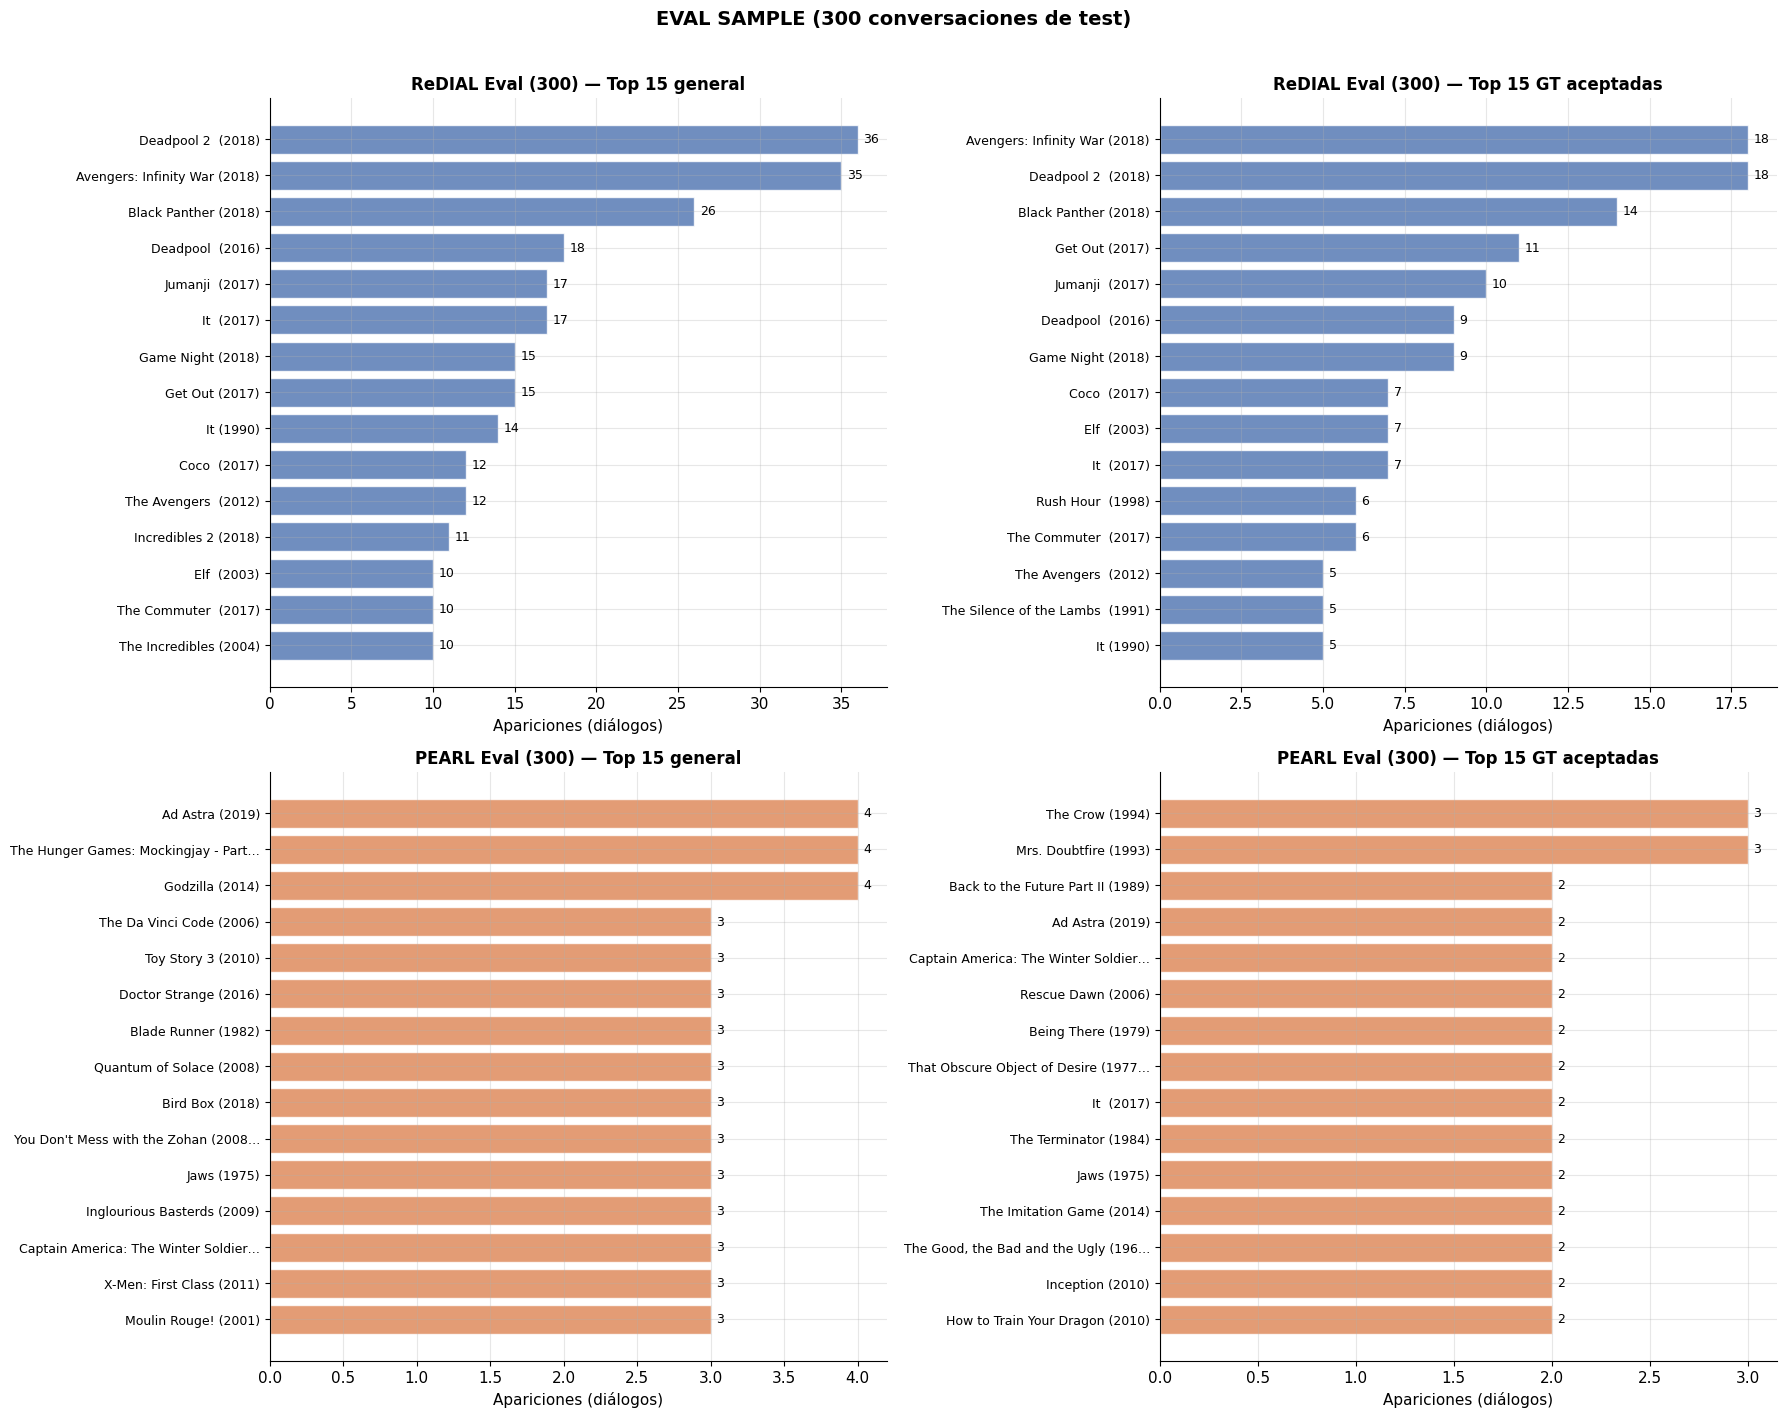

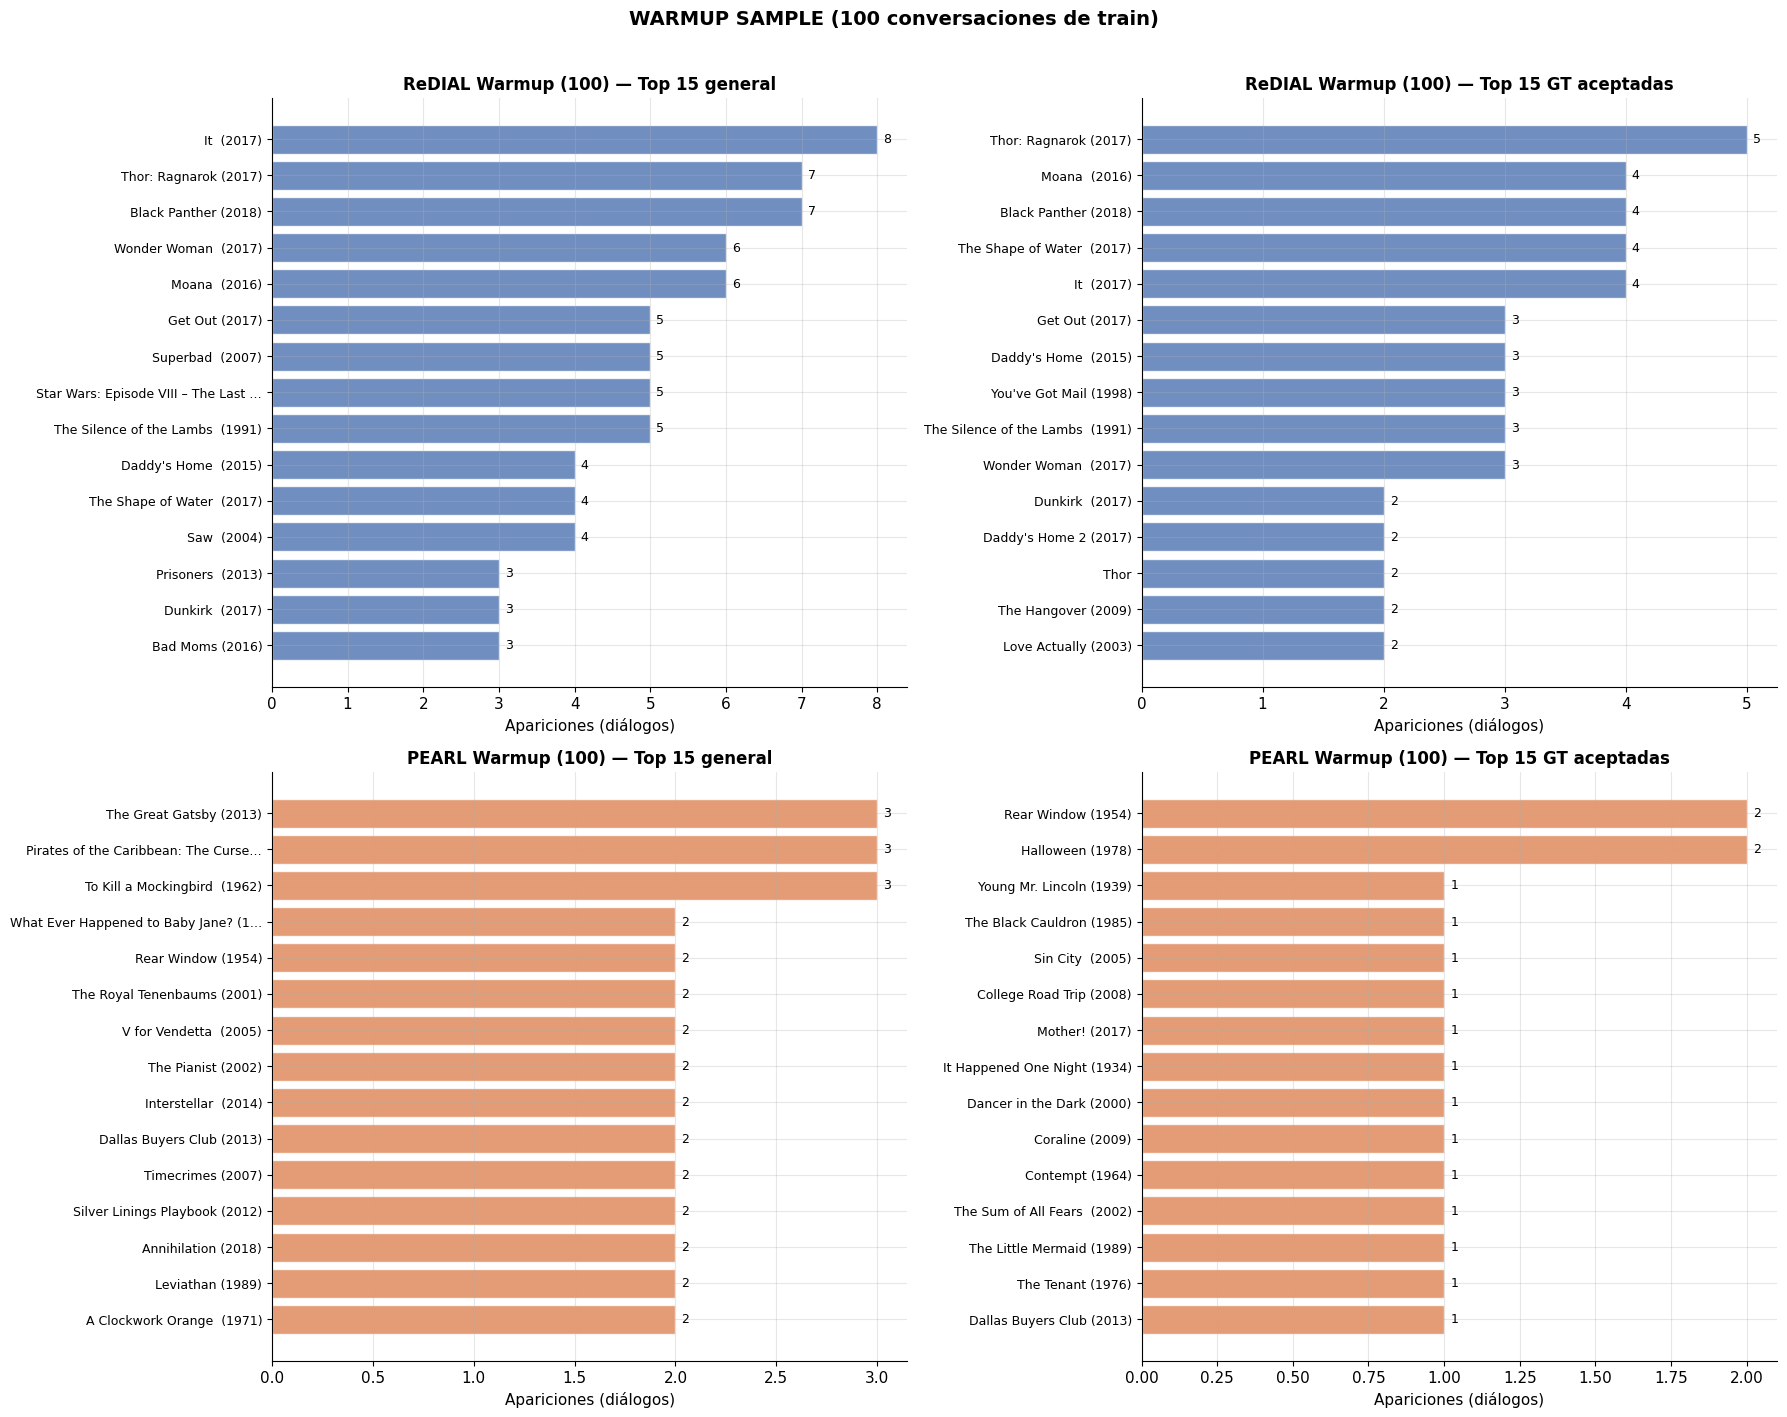

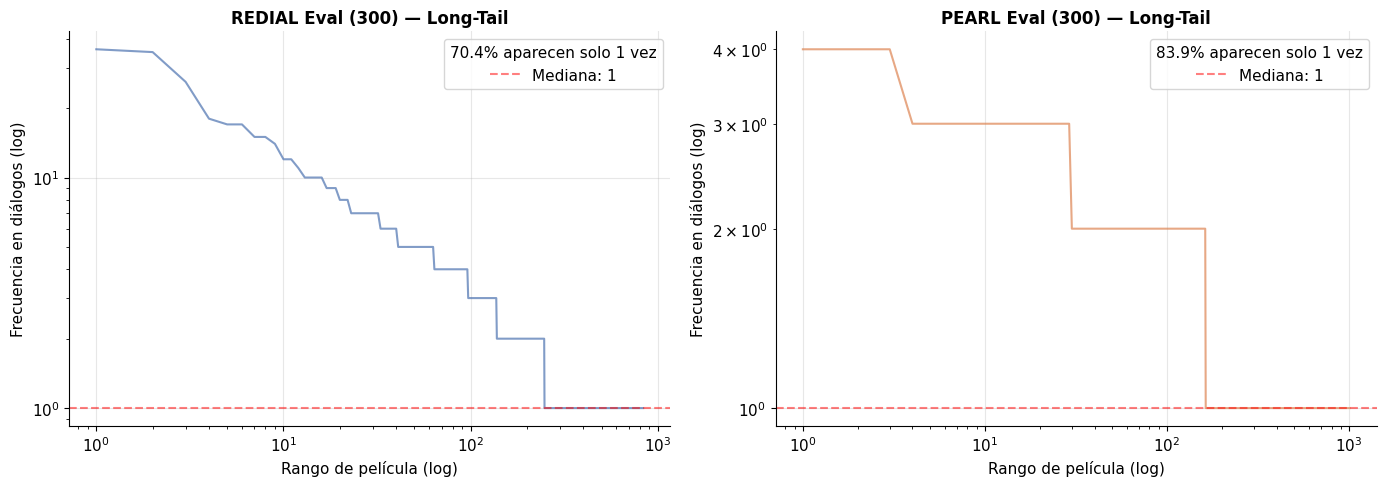


  RESUMEN DE FRECUENCIA — MUESTRAS

  REDIAL

    [eval300] (300 diálogos)
      Películas únicas (general): 834
      Películas únicas (GT):      538
      Frecuencia media (general): 1.94
      Frecuencia media (GT):      1.59
      Aparecen solo 1 vez:        587 (70.4%)
      GT solo 1 vez:              405 (75.3%)
      Más frecuente (general):    Deadpool 2  (2018) (36x)
      Más frecuente (GT):         Avengers: Infinity War (2018) (18x)

    [warmup100] (100 diálogos)
      Películas únicas (general): 389
      Películas únicas (GT):      244
      Frecuencia media (general): 1.39
      Frecuencia media (GT):      1.20
      Aparecen solo 1 vez:        301 (77.4%)
      GT solo 1 vez:              211 (86.5%)
      Más frecuente (general):    It  (2017) (8x)
      Más frecuente (GT):         Thor: Ragnarok (2017) (5x)

  PEARL

    [eval300] (300 diálogos)
      Películas únicas (general): 1,006
      Películas únicas (GT):      281
      Frecuencia media (general): 1.19
    

In [37]:
# ── Frecuencia de películas en muestras ──────────────────────────
freq_samples = {}
for ds in ["redial", "pearl"]:
    for split, label in [("eval_sample", "eval300"), ("warmup_sample", "warmup100")]:
        key = f"{ds}_{label}"
        gen, gt = count_freqs(data[ds][split])
        freq_samples[key] = {"general": gen, "gt": gt}
        print(f"{key} — Películas únicas (general): {len(gen)} | GT: {len(gt)}")

# =============================================
# TOP 15 — EVAL 300
# =============================================
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

plots_eval = [
    (freq_samples["redial_eval300"]["general"], "ReDIAL Eval (300) — Top 15 general", COLORS["redial"]),
    (freq_samples["redial_eval300"]["gt"], "ReDIAL Eval (300) — Top 15 GT aceptadas", COLORS["redial"]),
    (freq_samples["pearl_eval300"]["general"], "PEARL Eval (300) — Top 15 general", COLORS["pearl"]),
    (freq_samples["pearl_eval300"]["gt"], "PEARL Eval (300) — Top 15 GT aceptadas", COLORS["pearl"]),
]

for ax, (counter, title, color) in zip(axes.flat, plots_eval):
    top = counter.most_common(15)
    if not top:
        ax.set_title(title + " (sin datos)")
        continue
    names = [t[0][:35] + "…" if len(t[0]) > 35 else t[0] for t in top]
    counts = [t[1] for t in top]
    y_pos = np.arange(len(names))

    ax.barh(y_pos, counts, color=color, alpha=0.8, edgecolor="white")
    ax.set_yticks(y_pos)
    ax.set_yticklabels(names, fontsize=9)
    ax.invert_yaxis()
    ax.set_xlabel("Apariciones (diálogos)")
    ax.set_title(title, fontsize=12, fontweight="bold")
    for i, v in enumerate(counts):
        ax.text(v + max(counts) * 0.01, i, str(v), va="center", fontsize=9)

plt.suptitle("EVAL SAMPLE (300 conversaciones de test)", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

# =============================================
# TOP 15 — WARMUP 100
# =============================================
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

plots_warmup = [
    (freq_samples["redial_warmup100"]["general"], "ReDIAL Warmup (100) — Top 15 general", COLORS["redial"]),
    (freq_samples["redial_warmup100"]["gt"], "ReDIAL Warmup (100) — Top 15 GT aceptadas", COLORS["redial"]),
    (freq_samples["pearl_warmup100"]["general"], "PEARL Warmup (100) — Top 15 general", COLORS["pearl"]),
    (freq_samples["pearl_warmup100"]["gt"], "PEARL Warmup (100) — Top 15 GT aceptadas", COLORS["pearl"]),
]

for ax, (counter, title, color) in zip(axes.flat, plots_warmup):
    top = counter.most_common(15)
    if not top:
        ax.set_title(title + " (sin datos)")
        continue
    names = [t[0][:35] + "…" if len(t[0]) > 35 else t[0] for t in top]
    counts = [t[1] for t in top]
    y_pos = np.arange(len(names))

    ax.barh(y_pos, counts, color=color, alpha=0.8, edgecolor="white")
    ax.set_yticks(y_pos)
    ax.set_yticklabels(names, fontsize=9)
    ax.invert_yaxis()
    ax.set_xlabel("Apariciones (diálogos)")
    ax.set_title(title, fontsize=12, fontweight="bold")
    for i, v in enumerate(counts):
        ax.text(v + max(counts) * 0.01, i, str(v), va="center", fontsize=9)

plt.suptitle("WARMUP SAMPLE (100 conversaciones de train)", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

# =============================================
# LONG-TAIL EVAL 300
# =============================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, ds, color in zip(axes, ["redial", "pearl"], [COLORS["redial"], COLORS["pearl"]]):
    freqs = sorted(freq_samples[f"{ds}_eval300"]["general"].values(), reverse=True)
    ranks = np.arange(1, len(freqs) + 1)

    ax.loglog(ranks, freqs, color=color, alpha=0.7, linewidth=1.5)
    ax.set_xlabel("Rango de película (log)")
    ax.set_ylabel("Frecuencia en diálogos (log)")
    ax.set_title(f"{ds.upper()} Eval (300) — Long-Tail", fontsize=12, fontweight="bold")
    ax.grid(True, alpha=0.3)

    pct_once = sum(1 for f in freqs if f == 1) / len(freqs) * 100
    ax.axhline(y=np.median(freqs), color="red", linestyle="--", alpha=0.5,
               label=f"Mediana: {np.median(freqs):.0f}")
    ax.legend(title=f"{pct_once:.1f}% aparecen solo 1 vez")

plt.tight_layout()
plt.show()

# =============================================
# RESUMEN MUESTRAS
# =============================================
print("\n" + "=" * 65)
print("  RESUMEN DE FRECUENCIA — MUESTRAS")
print("=" * 65)

for ds in ["redial", "pearl"]:
    print(f"\n  {ds.upper()}")
    for label, n_sample in [("eval300", 300), ("warmup100", 100)]:
        key = f"{ds}_{label}"
        gen = freq_samples[key]["general"]
        gt = freq_samples[key]["gt"]
        freqs_g = list(gen.values())
        freqs_gt = list(gt.values())
        once_g = sum(1 for f in freqs_g if f == 1)
        once_gt = sum(1 for f in freqs_gt if f == 1)
        top1 = gen.most_common(1)[0] if gen else ("—", 0)
        top1_gt = gt.most_common(1)[0] if gt else ("—", 0)

        print(f"\n    [{label}] ({n_sample} diálogos)")
        print(f"      Películas únicas (general): {len(gen):,}")
        print(f"      Películas únicas (GT):      {len(gt):,}")
        print(f"      Frecuencia media (general): {np.mean(freqs_g):.2f}")
        print(f"      Frecuencia media (GT):      {np.mean(freqs_gt):.2f}")
        print(f"      Aparecen solo 1 vez:        {once_g:,} ({once_g/len(gen)*100:.1f}%)")
        print(f"      GT solo 1 vez:              {once_gt:,} ({once_gt/len(gt)*100:.1f}%)")
        print(f"      Más frecuente (general):    {top1[0]} ({top1[1]}x)")
        print(f"      Más frecuente (GT):         {top1_gt[0]} ({top1_gt[1]}x)")

print(f"\n{'=' * 65}")